In [1]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")

print("Path to dataset files:", path)
print(os.listdir(path))

/Users/tmchq/Dev/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 14.5M/14.5M [00:04<00:00, 3.37MB/s]

Extracting files...


Path to dataset files: /Users/tmchq/.cache/kagglehub/datasets/mashlyn/online-retail-ii-uci/versions/3
['online_retail_II.csv']


In [2]:
import sqlite3
import pandas as pd

# Загружаем CSV
df = pd.read_csv(path + '/online_retail_II.csv', encoding='latin-1')

# Создаём SQLite базу
conn = sqlite3.connect('retail.db')
df.to_sql('transactions', conn, if_exists='replace', index=False)

print(df.shape)
print(df.columns.tolist())

(1067371, 8)
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [4]:
query = """
SELECT
    COUNT(*) as total_rows,
    COUNT(DISTINCT "Customer ID") as unique_customers,
    COUNT(DISTINCT Invoice) as unique_invoices,
    MIN(InvoiceDate) as first_date,
    MAX(InvoiceDate) as last_date,
    SUM(CASE WHEN "Customer ID" IS NULL THEN 1 ELSE 0 END) as missing_customers
FROM transactions
"""
print(pd.read_sql(query, conn))

   total_rows  unique_customers  unique_invoices           first_date  \
0     1067371              5942            53628  2009-12-01 07:45:00   

             last_date  missing_customers  
0  2011-12-09 12:50:00             243007  


In [5]:
query_clean = """
CREATE TABLE IF NOT EXISTS transactions_clean AS
SELECT
    Invoice,
    StockCode,
    Quantity,
    InvoiceDate,
    Price,
    "Customer ID" as CustomerID,
    Country,
    SUBSTR(InvoiceDate, 1, 7) as YearMonth,
    Quantity * Price as Revenue
FROM transactions
WHERE
    "Customer ID" IS NOT NULL
    AND Quantity > 0
    AND Price > 0
    AND Invoice NOT LIKE 'C%'
"""

conn.execute("DROP TABLE IF EXISTS transactions_clean")
conn.execute(query_clean)
conn.commit()

print(pd.read_sql("SELECT COUNT(*) as rows FROM transactions_clean", conn))

     rows
0  805549


In [6]:
# Определяем когорту каждого покупателя как месяц первой покупки
query_cohorts = """
CREATE TABLE IF NOT EXISTS cohorts AS
SELECT
    CustomerID,
    MIN(YearMonth) as CohortMonth
FROM transactions_clean
GROUP BY CustomerID
"""

conn.execute("DROP TABLE IF EXISTS cohorts")
conn.execute(query_cohorts)
conn.commit()

# Считаем retention по когортам
query_retention = """
SELECT
    c.CohortMonth,
    t.YearMonth as TransactionMonth,
    COUNT(DISTINCT t.CustomerID) as Customers
FROM transactions_clean t
JOIN cohorts c ON t.CustomerID = c.CustomerID
GROUP BY c.CohortMonth, t.YearMonth
ORDER BY c.CohortMonth, t.YearMonth
"""

retention_df = pd.read_sql(query_retention, conn)
print(retention_df.head(10))

  CohortMonth TransactionMonth  Customers
0     2009-12          2009-12        955
1     2009-12          2010-01        337
2     2009-12          2010-02        319
3     2009-12          2010-03        406
4     2009-12          2010-04        363
5     2009-12          2010-05        343
6     2009-12          2010-06        360
7     2009-12          2010-07        327
8     2009-12          2010-08        321
9     2009-12          2010-09        346


In [7]:
# Считаем номер периода
retention_df['CohortMonth'] = pd.to_datetime(retention_df['CohortMonth'])
retention_df['TransactionMonth'] = pd.to_datetime(retention_df['TransactionMonth'])
retention_df['Period'] = (retention_df['TransactionMonth'].dt.year - retention_df['CohortMonth'].dt.year) * 12 + \
                         (retention_df['TransactionMonth'].dt.month - retention_df['CohortMonth'].dt.month)

cohort_matrix = retention_df.pivot_table(
    index='CohortMonth',
    columns='Period',
    values='Customers'
)

# Считаем проценты от первого месяца
cohort_size = cohort_matrix[0]
retention_matrix = cohort_matrix.divide(cohort_size, axis=0).round(3) * 100

print(retention_matrix.iloc[:5, :6])

Period           0     1     2     3     4     5
CohortMonth                                     
2009-12-01   100.0  35.3  33.4  42.5  38.0  35.9
2010-01-01   100.0  20.6  31.1  30.5  26.4  30.0
2010-02-01   100.0  23.8  22.5  29.1  24.6  20.1
2010-03-01   100.0  19.0  23.0  24.2  23.3  20.3
2010-04-01   100.0  19.4  19.4  16.3  18.4  22.4


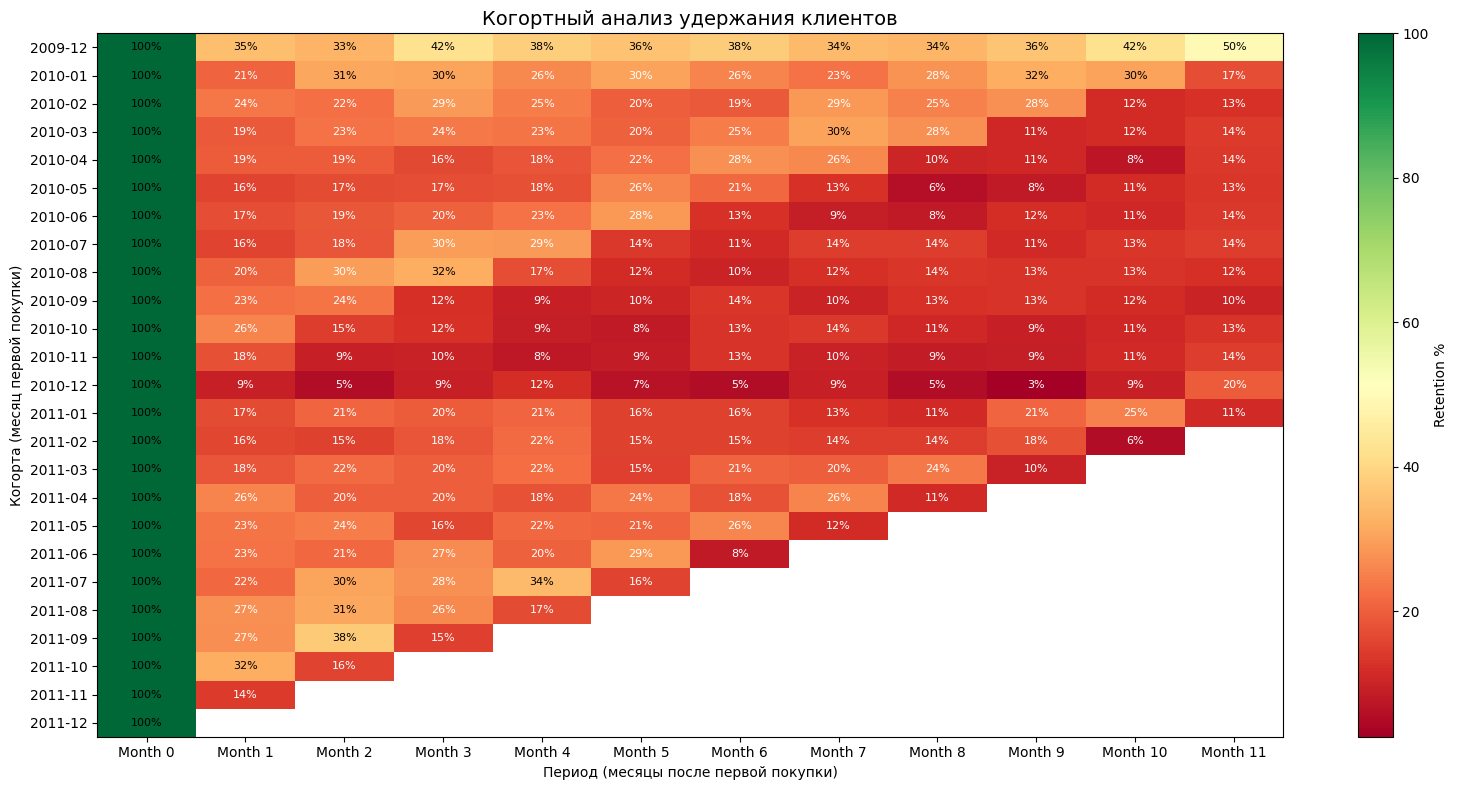

In [15]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(16, 8))

# Берём первые 12 периодов
matrix_plot = retention_matrix.iloc[:, :12]

im = ax.imshow(matrix_plot.values, cmap="RdYlGn", aspect='auto')

ax.set_xticks(range(len(matrix_plot.columns)))
ax.set_xticklabels([f'Month {i}' for i in matrix_plot.columns])
ax.set_yticks(range(len(matrix_plot.index)))
ax.set_yticklabels([d.strftime('%Y-%m') for d in matrix_plot.index])

for i in range(len(matrix_plot.index)):
    for j in range(len(matrix_plot.columns)):
        val = matrix_plot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                   fontsize=8, color='black' if val > 30 else 'white')

plt.colorbar(im, ax=ax, label='Retention %')
ax.set_title('Когортный анализ удержания клиентов', fontsize=14)
ax.set_xlabel('Период (месяцы после первой покупки)')
ax.set_ylabel('Когорта (месяц первой покупки)')

plt.tight_layout()
plt.show()

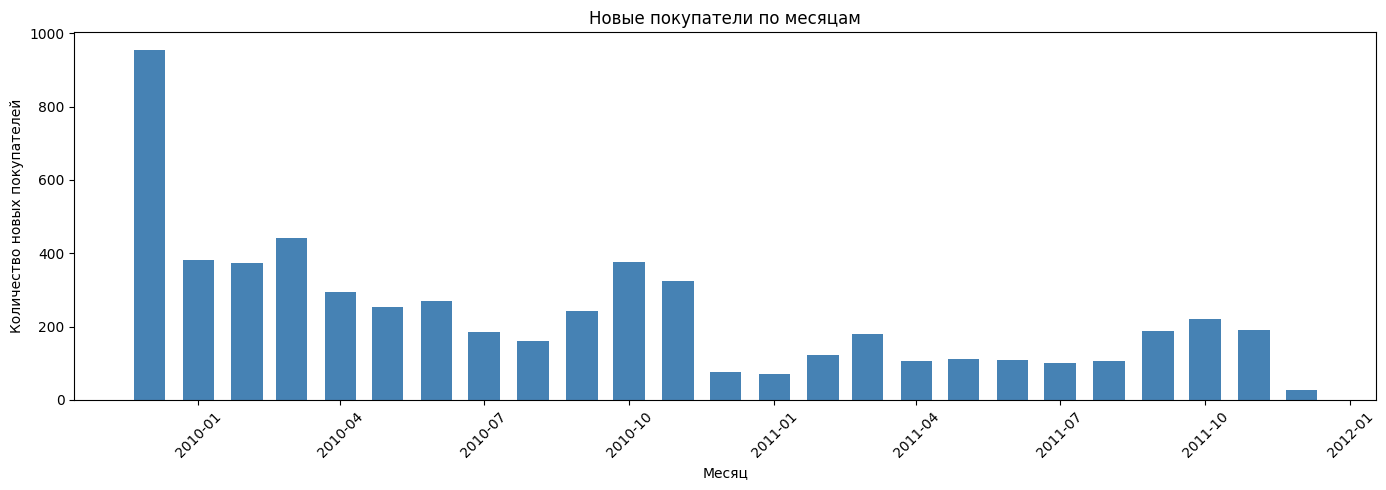

   CohortMonth  NewCustomers
0   2009-12-01           955
1   2010-01-01           383
2   2010-02-01           374
3   2010-03-01           443
4   2010-04-01           294
5   2010-05-01           254
6   2010-06-01           270
7   2010-07-01           186
8   2010-08-01           162
9   2010-09-01           243
10  2010-10-01           377
11  2010-11-01           325
12  2010-12-01            76
13  2011-01-01            71
14  2011-02-01           124
15  2011-03-01           179
16  2011-04-01           106
17  2011-05-01           111
18  2011-06-01           108
19  2011-07-01           102
20  2011-08-01           106
21  2011-09-01           189
22  2011-10-01           221
23  2011-11-01           191
24  2011-12-01            28


In [16]:
cohort_sizes = pd.read_sql("""
SELECT
    CohortMonth,
    COUNT(DISTINCT CustomerID) as NewCustomers
FROM cohorts
GROUP BY CohortMonth
ORDER BY CohortMonth
""", conn)

cohort_sizes['CohortMonth'] = pd.to_datetime(cohort_sizes['CohortMonth'])

plt.figure(figsize=(14, 5))
plt.bar(cohort_sizes['CohortMonth'], cohort_sizes['NewCustomers'], color='steelblue', width=20)
plt.title('Новые покупатели по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество новых покупателей')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(cohort_sizes)

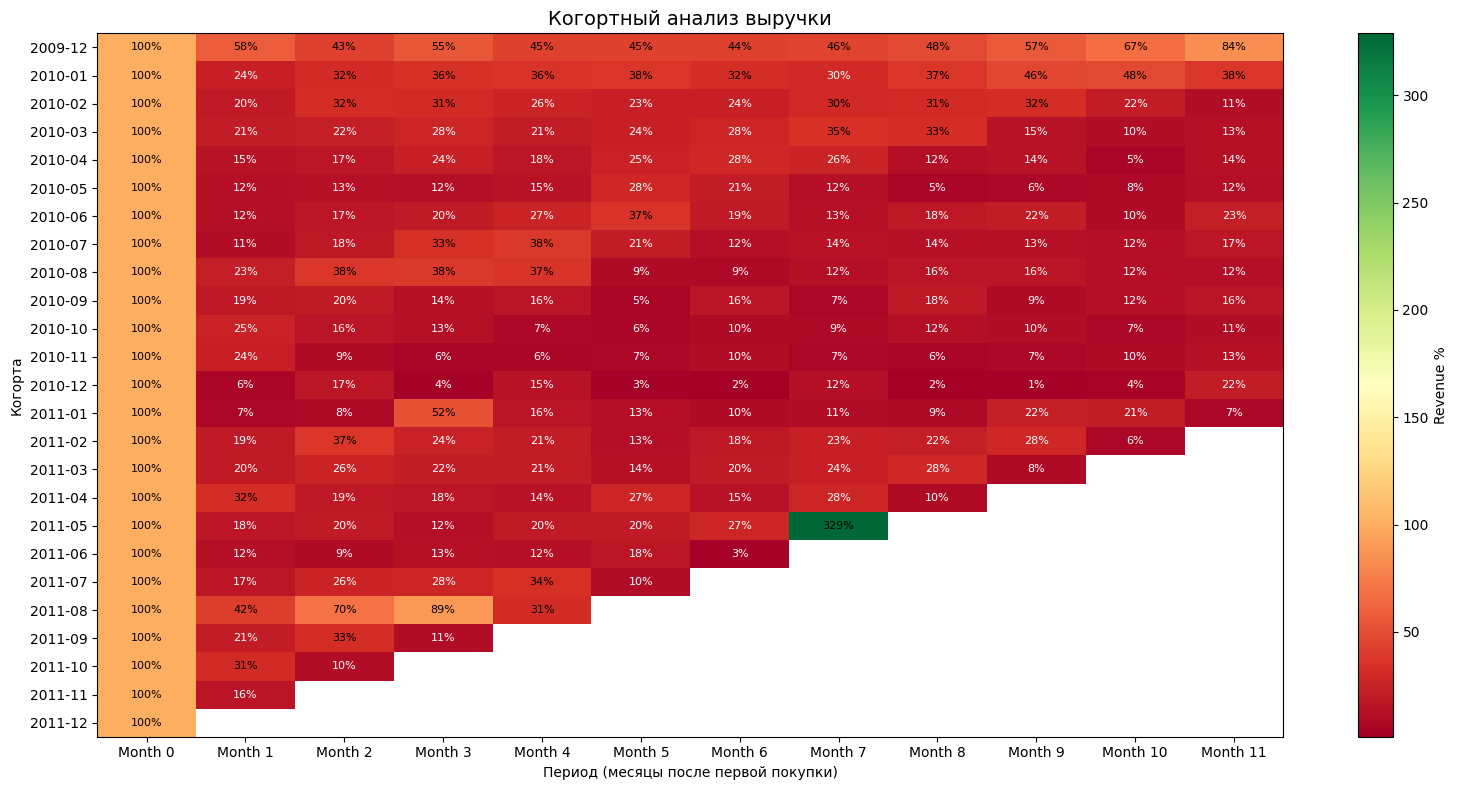

In [17]:
query_revenue = """
SELECT
    c.CohortMonth,
    t.YearMonth as TransactionMonth,
    SUM(t.Revenue) as TotalRevenue
FROM transactions_clean t
JOIN cohorts c ON t.CustomerID = c.CustomerID
GROUP BY c.CohortMonth, t.YearMonth
ORDER BY c.CohortMonth, t.YearMonth
"""

revenue_df = pd.read_sql(query_revenue, conn)
revenue_df['CohortMonth'] = pd.to_datetime(revenue_df['CohortMonth'])
revenue_df['TransactionMonth'] = pd.to_datetime(revenue_df['TransactionMonth'])
revenue_df['Period'] = (revenue_df['TransactionMonth'].dt.year - revenue_df['CohortMonth'].dt.year) * 12 + \
                       (revenue_df['TransactionMonth'].dt.month - revenue_df['CohortMonth'].dt.month)

revenue_matrix = revenue_df.pivot_table(
    index='CohortMonth',
    columns='Period',
    values='TotalRevenue'
)

# Нормализуем к первому месяцу
revenue_pct = revenue_matrix.divide(revenue_matrix[0], axis=0).round(3) * 100

fig, ax = plt.subplots(figsize=(16, 8))
matrix_plot = revenue_pct.iloc[:, :12]

im = ax.imshow(matrix_plot.values, cmap='RdYlGn', aspect='auto')

ax.set_xticks(range(len(matrix_plot.columns)))
ax.set_xticklabels([f'Month {i}' for i in matrix_plot.columns])
ax.set_yticks(range(len(matrix_plot.index)))
ax.set_yticklabels([d.strftime('%Y-%m') for d in matrix_plot.index])

import numpy as np
for i in range(len(matrix_plot.index)):
    for j in range(len(matrix_plot.columns)):
        val = matrix_plot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                   fontsize=8, color='black' if val > 30 else 'white')

plt.colorbar(im, ax=ax, label='Revenue %')
ax.set_title('Когортный анализ выручки', fontsize=14)
ax.set_xlabel('Период (месяцы после первой покупки)')
ax.set_ylabel('Когорта')
plt.tight_layout()
plt.show()

Средний retention по всем когортам

Month 1  (30 дней):  21.2%
Month 3  (90 дней):  21.6%
Month 6  (180 дней): 17.8%
Month 12 (год):      16.4%


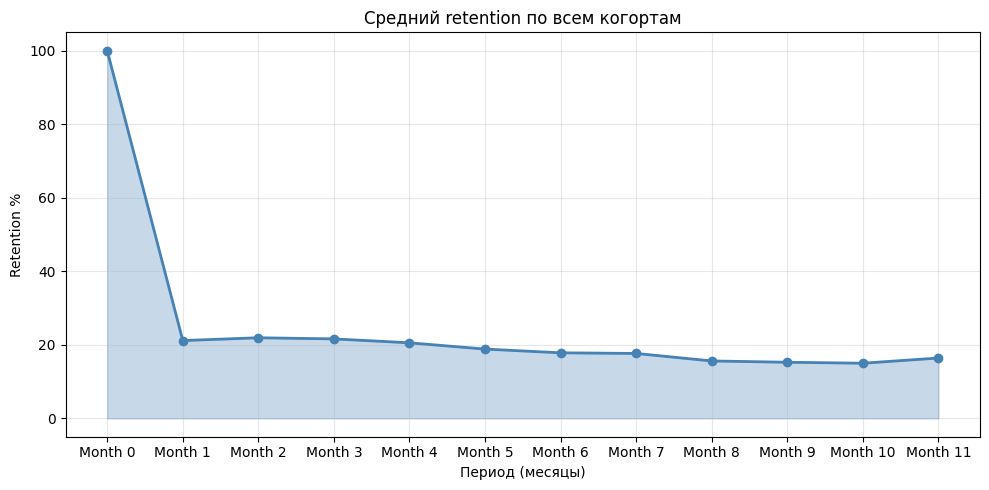

In [19]:
print("Средний retention по всем когортам\n")

avg_retention = retention_matrix.mean()

print(f"Month 1  (30 дней):  {avg_retention[1]:.1f}%")
print(f"Month 3  (90 дней):  {avg_retention[3]:.1f}%")
print(f"Month 6  (180 дней): {avg_retention[6]:.1f}%")
print(f"Month 12 (год):      {avg_retention[11]:.1f}%")

# График среднего retention
plt.figure(figsize=(10, 5))
avg_ret = retention_matrix.mean()[:12]
plt.plot(avg_ret.index, avg_ret.values, marker='o', color='steelblue', linewidth=2)
plt.fill_between(avg_ret.index, avg_ret.values, alpha=0.3, color='steelblue')
plt.title('Средний retention по всем когортам')
plt.xlabel('Период (месяцы)')
plt.ylabel('Retention %')
plt.xticks(range(12), [f'Month {i}' for i in range(12)])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

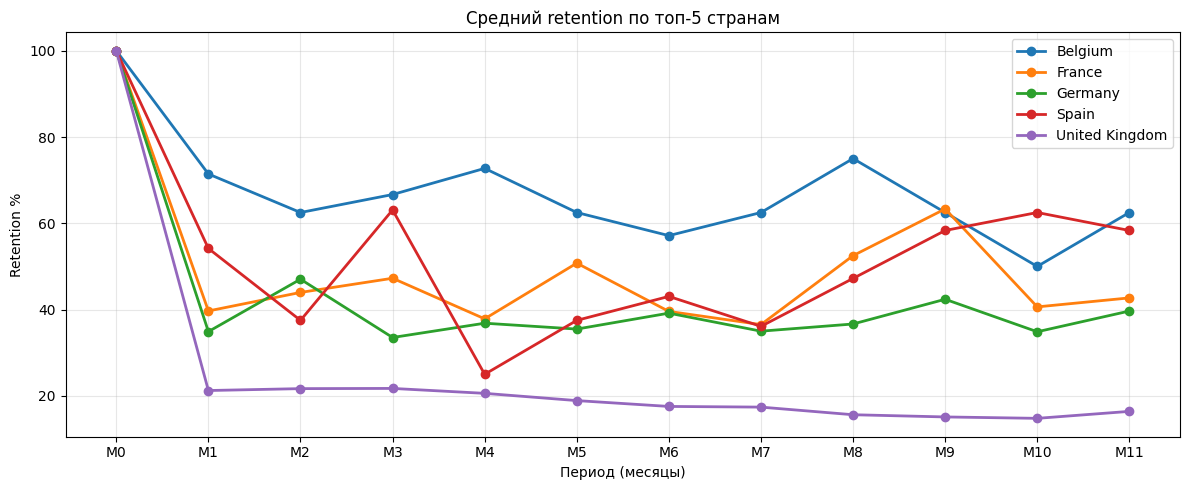

In [20]:
query_countries = """
SELECT
    c.CohortMonth,
    t.YearMonth,
    t.Country,
    COUNT(DISTINCT t.CustomerID) as Customers
FROM transactions_clean t
JOIN cohorts c ON t.CustomerID = c.CustomerID
WHERE t.Country IN (
    SELECT Country
    FROM transactions_clean
    GROUP BY Country
    ORDER BY COUNT(DISTINCT CustomerID) DESC
    LIMIT 5
)
GROUP BY c.CohortMonth, t.YearMonth, t.Country
"""

country_df = pd.read_sql(query_countries, conn)
country_df['CohortMonth'] = pd.to_datetime(country_df['CohortMonth'])
country_df['TransactionMonth'] = pd.to_datetime(country_df['YearMonth'])
country_df['Period'] = (country_df['TransactionMonth'].dt.year - country_df['CohortMonth'].dt.year) * 12 + \
                       (country_df['TransactionMonth'].dt.month - country_df['CohortMonth'].dt.month)

# Средний retention по странам
fig, ax = plt.subplots(figsize=(12, 5))

for country in country_df['Country'].unique():
    c_df = country_df[country_df['Country'] == country]
    pivot = c_df.pivot_table(index='CohortMonth', columns='Period', values='Customers')
    avg_ret = (pivot.divide(pivot[0], axis=0) * 100).mean()[:12]
    ax.plot(avg_ret.index, avg_ret.values, marker='o', label=country, linewidth=2)

ax.set_title('Средний retention по топ-5 странам')
ax.set_xlabel('Период (месяцы)')
ax.set_ylabel('Retention %')
ax.legend()
ax.set_xticks(range(12))
ax.set_xticklabels([f'M{i}' for i in range(12)])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()